# **Customer Churn Prediction**

This notebook summarizes the performance of supervised machine learning models for predicting customer churn in a telecommunications dataset.

**Models evaluated:**

- Logistic Regression
- Random Forest
- XGBoost
- CatBoost
- LightGBM

## **Objective**

This report evaluates several supervised machine learning algorithms for customer churn prediction. The models are compared using cross-validation during hyperparameter tuning and are subsequently evaluated on a separate holdout dataset. Since customer churn is an imbalanced binary classification problem, model performance is assessed primarily using precision, recall, and F1 score, with additional evaluation through confusion matrices, ROC curves, Precision-Recall curves, feature importance analysis, and decision threshold analysis. The best-performing model is then identified for potential customer retention applications.

## **Dataset**

The target variable is whether a customer churns from the telecommunications service.

The dataset contains both numerical usage statistics and categorical customer information.

| Variable Group | Examples |
|----------------|----------|
| Customer account information | Account length, state, area code |
| Subscription plans | International plan, voice mail plan |
| Call usage statistics | Day, evening, night, and international call minutes and number of calls |
| Customer service interactions | Number of customer service calls |

The processed dataset is divided into separate training and holdout test sets. The training dataset is used for model development, hyperparameter tuning, and cross-validation, while the holdout dataset is reserved exclusively for the final evaluation of model performance on unseen customers. :contentReference[oaicite:0]{index=0}

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve, PrecisionRecallDisplay, RocCurveDisplay, ConfusionMatrixDisplay

In [2]:
churn_data = pd.read_csv('..//data//processed//churn_known.csv')
churn_test = pd.read_csv('..//data//processed//churn_holdout.csv')
actual_pred = pd.read_csv('..//outputs//tables//actual_pred.csv')
opt_cv = pd.read_csv('..//outputs//tables//opt_cv.csv', index_col = 0)

In [3]:
data_train = churn_data
data_test = churn_test
target_col = 'churn'

X_train = data_train.drop(columns = target_col)
y_train = data_train[target_col]

X_test = data_test.drop(columns = target_col)
y_test = data_test[target_col]

In [4]:
cat_model = joblib.load("../models/catboost.joblib")
rf_model = joblib.load("../models/random_forest.joblib")
xgb_model = joblib.load("../models/xgboost.joblib")
lgbm_model = joblib.load("../models/lightgbm.joblib")
log_model = joblib.load("../models/logistic.joblib")

To recap, the customer churn dataset has the following numerical and categorical columns, respectively.

In [5]:
data_train.select_dtypes(include = 'number').columns

Index(['account_length', 'number_vmail_messages', 'total_day_minutes',
       'total_day_calls', 'total_eve_minutes', 'total_eve_calls',
       'total_night_minutes', 'total_night_calls', 'total_intl_minutes',
       'total_intl_calls', 'number_customer_service_calls'],
      dtype='object')

In [6]:
data_train.select_dtypes(exclude = 'number').columns

Index(['state', 'area_code', 'international_plan', 'voice_mail_plan', 'churn'], dtype='object')

## **Evaluation Metrics**

For this particular problem, it is important to contextualize the evaluation metrics discussed below.

* Maximizing **recall** means minimizing *false negatives* (customers predicted to stay who actually churn). This is the most important metric to maximize if the objective is to identify as many potential churners as possible. Although doing so may incorrectly classify some non-churners as churners, these customers can instead be interpreted as being at risk of churning. The relevant departments may then target these customers with retention efforts.
* Maximizing **precision** means minimizing *false positives* (customers predicted to churn who actually stay). While identifying customers at risk of churn is important, it is equally important to ensure that retention campaigns are directed toward customers who are most likely to churn, thereby minimizing unnecessary campaign costs.
* The model with the highest **F1 score** achieves the best balance between minimizing *false negatives* and *false positives*.

In [7]:
def eval_metrics(y_true, y_pred):

    metrics = {'Precision': precision_score(y_true = y_true, y_pred = y_pred),
               'Recall': recall_score(y_true = y_true, y_pred = y_pred),
               'F1': f1_score(y_true = y_true, y_pred = y_pred)}

    return metrics

In [8]:
metric_df = pd.DataFrame() 
for col in actual_pred.columns.drop('Actual'):
    metric = pd.DataFrame(eval_metrics(actual_pred['Actual'], actual_pred[col]), index = [col])
    metric_df = pd.concat([metric_df, metric])

In [9]:
results_df = pd.concat([metric_df, opt_cv], axis=1)
results_df = results_df.sort_values('F1', ascending=False)

results_df

,Precision,Recall,F1,CV F1
LightGBM,0.940000,0.783333,0.854545,0.845712
XGBoost,0.913462,0.791667,0.848214,0.839600
CatBoost,0.928571,0.758333,0.834862,0.855482
RandomForest,0.902913,0.775000,0.834081,0.825803
LogisticRegression,0.340824,0.758333,0.470284,0.488649


Among the evaluated models, **LightGBM** achieved the highest F1 score (0.855) on the unseen holdout dataset while also obtaining the highest precision (0.940). Although CatBoost achieved the highest cross-validation F1 score (0.855), its holdout performance was slightly lower than that of LightGBM. The close agreement between the cross-validation and holdout F1 scores across the tree-based models suggests that the hyperparameter tuning procedure generalized well and did not exhibit significant overfitting. Logistic Regression performed considerably worse than the ensemble-based approaches, implying that nonlinear decision boundaries are better suited to this dataset.

## **Confusion Matrices**

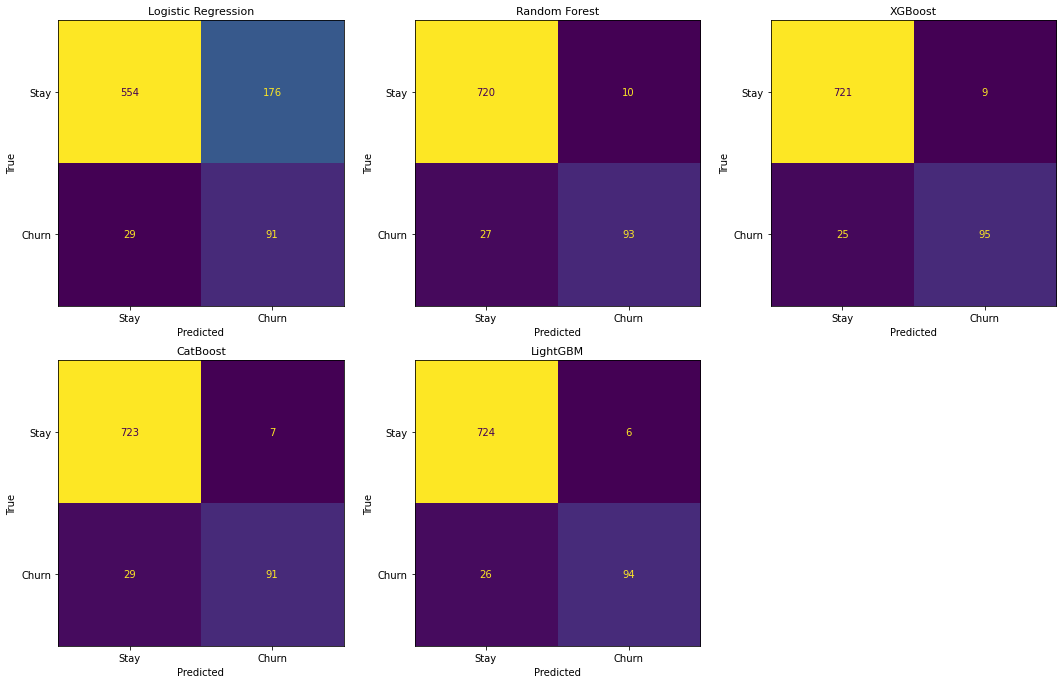

In [10]:
models = {'Logistic Regression': 'LogisticRegression',
          'Random Forest': 'RandomForest',
          'XGBoost': 'XGBoost',
          'CatBoost': 'CatBoost',
          'LightGBM': 'LightGBM'}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for ax, (title, col) in zip(axes, models.items()):
    disp = ConfusionMatrixDisplay.from_predictions(actual_pred['Actual'], actual_pred[col], display_labels = ['Stay', 'Churn'], colorbar=False, ax=ax)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')


fig.delaxes(axes[-1])
fig.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig('..//outputs//figures//confusion_matrix.jpg', dpi = 300, bbox_inches = 'tight')
plt.savefig('..//outputs//figures//confusion_matrix.png', dpi = 300, bbox_inches = 'tight')
plt.show()

Logistic Regression predicts many customers as churners, resulting in relatively few missed churners but a large number of false positives. While this maximizes recall, it would also increase the cost of retention campaigns because many customers receiving interventions would not actually churn. The tree-based models reduce false positives substantially while maintaining high recall. Among them, LightGBM misclassified only six non-churners as churners while correctly identifying 94 of the 120 actual churners. This balance between precision and recall explains why it achieved the highest F1 score. Overall, the confusion matrices indicate that the ensemble methods provide a more practical balance between identifying customers at risk and minimizing unnecessary retention efforts.

## **Receiver Operating Characteristic (ROC) Curves**

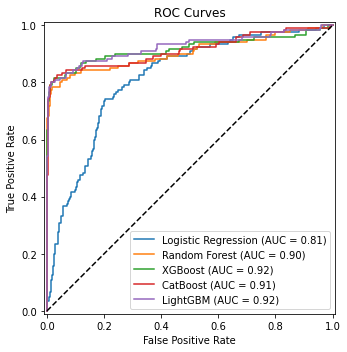

In [11]:
model_dict = {'Logistic Regression': log_model,
              'Random Forest': rf_model,
              'XGBoost': xgb_model,
              'CatBoost': cat_model,
              'LightGBM': lgbm_model}

fig, ax = plt.subplots(figsize=(20, 5))

for name, model in model_dict.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--')
ax.set(title="ROC Curves", xlabel="False Positive Rate", ylabel="True Positive Rate")

fig.tight_layout()
plt.savefig('..//outputs//figures//ROC.jpg', dpi = 300, bbox_inches = 'tight')
plt.savefig('..//outputs//figures//ROC.png', dpi = 300, bbox_inches = 'tight')
plt.show()

All four ensemble models produced ROC curves that are clustered closely together, indicating similar discrimination ability across different classification thresholds. Logistic Regression performed noticeably worse, confirming that its linear decision boundary is less suitable for this dataset. Although ROC curves provide an overview of ranking performance, they should not be used alone to select the final model for an imbalanced classification problem. Since customer churn represents the minority class, precision, recall, and F1 score provide a more informative assessment of practical performance.

## **Precision-Recall Curves**

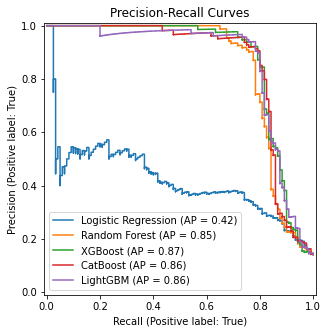

In [12]:
plt.figure(figsize=(20, 5))

for name, model in model_dict.items():
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=plt.gca(), name=name)

plt.title("Precision-Recall Curves")
plt.savefig('..//outputs//figures//PR.jpg', dpi = 300, bbox_inches = 'tight')
plt.savefig('..//outputs//figures//PR.png', dpi = 300, bbox_inches = 'tight')
plt.show()

The four ensemble models maintain both high precision and high recall over a wide range of thresholds, while Logistic Regression experiences a much sharper decline in precision. This indicates that the ensemble methods identify churning customers more reliably without producing a large number of false positives. **LightGBM** and **XGBoost** achieve the largest areas under the Precision-Recall curve, which is consistent with their strong F1 scores on the holdout dataset. The agreement between these different evaluation metrics provides additional confidence that their performance is not due to a favorable decision threshold alone.

## **Feature Importance**

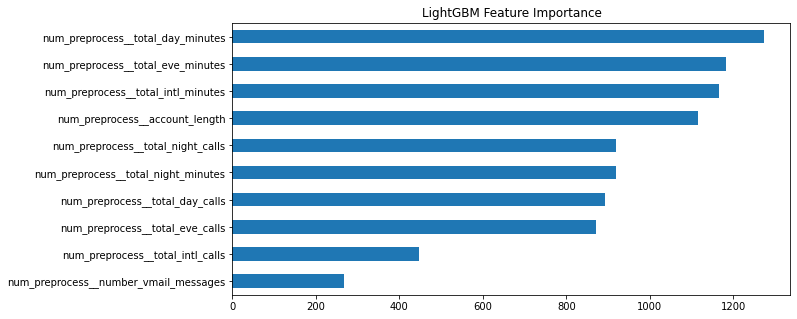

In [13]:
lgbm_importance = pd.Series(
    lgbm_model.best_estimator_.named_steps['lgbmclassifier'].feature_importances_,
    index = lgbm_model.best_estimator_.named_steps['columntransformer'].get_feature_names_out())

plt.figure(figsize=(10,5))
lgbm_importance.head(10).sort_values().plot(kind='barh')
plt.title("LightGBM Feature Importance")
plt.savefig('..//outputs//figures//LGBM_feats.jpg', dpi = 300, bbox_inches = 'tight')
plt.savefig('..//outputs//figures//LGBM_feats.png', dpi = 300, bbox_inches = 'tight')
plt.show()

The most influential features are dominated by customer usage statistics, particularly total daytime, evening, and international call minutes. These variables contribute significantly more than categorical attributes such as state or area code. This result suggests that customer behavior is more informative than customer demographics for predicting churn. Customers who exhibit unusual calling patterns are more distinguishable from the rest of the customer base than customers who simply belong to a particular geographic region. It should be noted that feature importance reflects a variable's contribution to the model's predictions rather than a causal relationship with customer churn.

## **Decision Threshold**

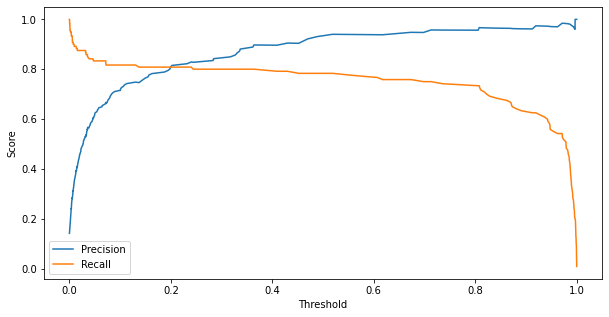

In [14]:
prob = lgbm_model.predict_proba(X_test)[:,1]

precision, recall, threshold = precision_recall_curve(y_test, prob)

plt.figure(figsize=(10,5))
plt.plot(threshold, precision[:-1], label='Precision')
plt.plot(threshold, recall[:-1], label='Recall')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.savefig('..//outputs//figures//LGBM_thresh.jpg', dpi = 300, bbox_inches = 'tight')
plt.savefig('..//outputs//figures//LGBM_thresh.png', dpi = 300, bbox_inches = 'tight')
plt.show()

Increasing the decision threshold increases precision while decreasing recall, whereas lowering the threshold has the opposite effect. All models were evaluated using the default threshold of 0.5, which, in the case of LightGBM, produced a precision of 0.94 and a recall of 0.78 on the holdout dataset. This operating point provides a strong balance between identifying customers likely to churn and minimizing unnecessary retention efforts. Although lower thresholds would identify more churning customers, they would also increase the number of customers incorrectly classified as churners. Conversely, higher thresholds would reduce false positives but would miss a larger proportion of customers who eventually churn. Since the objective of this project is to balance precision and recall, the default threshold provides a reasonable operating point. A different threshold may be preferred if future business requirements prioritize either recall or precision more heavily.

## **Conclusion**

Five supervised learning models were evaluated for customer churn prediction using hyperparameter tuning and a separate holdout dataset. Ensemble tree-based methods consistently outperformed Logistic Regression, indicating that nonlinear relationships are important for modeling customer churn. Among the evaluated models, **LightGBM** achieved the highest holdout F1 score while also maintaining the highest precision. **XGBoost** produced nearly identical performance, suggesting that either model would be a reasonable choice. CatBoost obtained the strongest cross-validation performance but experienced a slight reduction on the holdout dataset. Overall, the results indicate that the selected LightGBM model generalizes well to unseen customers and provides a good balance between identifying customers likely to churn and limiting unnecessary retention efforts.